In [1]:
import os

if os.getcwd().endswith("scripts"):
    os.chdir("..")
os.getcwd()

'/mnt/mergerfs/yuzihan/MergedWorkSpace/44-AI4Astronomy/AI4Astronomy'

# Plot Nature 2021 waiting-time and DM-evolution comparisons.

This script mirrors ``scripts/260624 Nature2021 energy distribution.ipynb``:
it rebuilds the BlinkVerse-derived tasks, overlays the SR Agent result, and
adds the simple model reported in Nature 2021.

Outputs:
    vibe/260624_nature2021_waiting_time_dm_evolution.png
    vibe/260624_nature2021_waiting_time_dm_metrics.csv

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from argparse import Namespace
from scipy.optimize import curve_fit
from sr_agent.utils.plot import get_fig
from scripts.run_blinkverse_sr_agent import build_task
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


exp_path = Path("logs/overnight_260623_v3/nature2021/waiting_time")
args = Namespace(**json.load(open(exp_path / "args.json", encoding="utf-8")))
print(
    f"task={args.task!r}, "
    f"bins={args.bins!r}, "
    f"data_dir={args.data_dir!r}"
)

X, y, problem = build_task(args)
data = X | y
data


task='nature2021_waiting_time', bins=40, data_dir='data/blinkverse'


{'log10_wait_s': array([-3.97266582, -3.7882464 , -3.60382698, -3.41940756, -3.23498814,
        -3.05056872, -2.8661493 , -2.68172988, -2.49731046, -2.31289104,
        -2.12847162, -1.9440522 , -1.75963278, -1.57521336, -1.39079394,
        -1.20637452, -1.0219551 , -0.83753568, -0.65311627, -0.46869685,
        -0.28427743, -0.09985801,  0.08456141,  0.26898083,  0.45340025,
         0.63781967,  0.82223909,  1.00665851,  1.19107793,  1.37549735,
         1.55991677,  1.74433619,  1.92875561,  2.11317503,  2.29759445,
         2.48201387,  2.66643329,  2.85085271,  3.03527213,  3.21969155]),
 'waiting_time_density': array([0.02020779, 0.02694371, 0.00673593, 0.04041557, 0.03367964,
        0.0471515 , 0.07746318, 0.15829432, 0.12461468, 0.1414545 ,
        0.10777486, 0.10440689, 0.03704761, 0.04041557, 0.03367964,
        0.05388743, 0.03031168, 0.03031168, 0.02357575, 0.01683982,
        0.00673593, 0.03031168, 0.01683982, 0.03031168, 0.06062336,
        0.094303  , 0.11451078, 0.

In [3]:
# AI-discovered formula from the original run with polynomial_fit enabled.
print(json.load(open(exp_path / 'result.json'))['best_formula'])
print('No-polynomial rerun best:', json.load(open('logs/260624_no_poly/waiting_time_no_poly/result.json'))['best_formula'])

def f_ai(x: np.ndarray) -> np.ndarray:
    """Original best formula in logs/overnight_260623_v3/nature2021/waiting_time/result.json."""
    return (
        0.01788048669378694
        + 0.024391172669269327 * x
        + 0.09170612421299247 * x**2
        + 0.048251605386074044 * x**3
        - 0.0009789477218960657 * x**4
        + 0.01938387335067988 * x**5
        + 0.00906885369420862 * x**6
        - 0.012328917284609357 * x**7
        - 0.0045783672397683856 * x**8
        + 0.0018933496915945604 * x**9
        + 0.0006900051688614158 * x**10
        - 0.00011136323797082967 * x**11
        - 4.143227360003151e-05 * x**12
        + 2.0757306960519437e-06 * x**13
        + 8.348490852984282e-07 * x**14
        + 1.142882249279692e-09 * x**15
    )


def f_ai2(x: np.ndarray) -> np.ndarray:
    """No-polynomial rerun: interpretable single log-normal peak."""
    return 0.5663971507610441 * np.exp(-((x - 1.8327758178519318) / 0.769951747540949) ** 2)


def f_ai3(x: np.ndarray) -> np.ndarray:
    """No-polynomial rerun: interpretable two-component log-normal mixture."""
    return (
        0.1310751289860215 * np.exp(-1.4675486581006598 * (x + 2.396127514054202) ** 2)
        + 0.5663943346706628 * np.exp(-1.6868343401692323 * (x - 1.8327737988868844) ** 2)
    )


def f_ai4(x: np.ndarray) -> np.ndarray:
    """No-polynomial rerun final best; lower MSE but less interpretable due cancellation."""
    return (
        9.036406665373155 * np.exp(-(x + 1.1955540815989276) ** 2 / (1.9806026780540305 * 0.9600816208812445 ** 2))
        + 0.569151992491104 * np.exp(-(x - 1.8541378990732786) ** 2 / (1.962014976981367 * 0.5250301983697402 ** 2))
        - 9.01018354453177 * np.exp(-(x + 1.1882364555979417) ** 2 / (1.7773115801494954 * 1.0035808840900158 ** 2))
    )


0.01788048669378694 * 1 + 0.024391172669269327 * log10_wait_s + 0.09170612421299247 * log10_wait_s ** 2 + 0.048251605386074044 * log10_wait_s ** 3 + -0.0009789477218960657 * log10_wait_s ** 4 + 0.01938387335067988 * log10_wait_s ** 5 + 0.00906885369420862 * log10_wait_s ** 6 + -0.012328917284609357 * log10_wait_s ** 7 + -0.0045783672397683856 * log10_wait_s ** 8 + 0.0018933496915945604 * log10_wait_s ** 9 + 0.0006900051688614158 * log10_wait_s ** 10 + -0.00011136323797082967 * log10_wait_s ** 11 + -4.143227360003151e-05 * log10_wait_s ** 12 + 2.0757306960519437e-06 * log10_wait_s ** 13 + 8.348490852984282e-07 * log10_wait_s ** 14 + 1.142882249279692e-09 * log10_wait_s ** 15
No-polynomial rerun best: 9.036406665373155 * exp(-(log10_wait_s - -1.1955540815989276) ** 2 / (1.9806026780540305 * 0.9600816208812445 ** 2)) + 0.569151992491104 * exp(-(log10_wait_s - 1.8541378990732786) ** 2 / (1.962014976981367 * 0.5250301983697402 ** 2)) + -9.01018354453177 * exp(-(log10_wait_s - -1.18823645559

In [4]:
x = np.asarray(data["log10_wait_s"], dtype=float)
y = np.asarray(data["waiting_time_density"], dtype=float)
order = np.argsort(x)
x, y = x[order], y[order]

# Nature 2021 Fig. 3 reports three fitted peak waiting times:
# 3.4 ms, 70 s, and 220 s.  Here we fix those peak locations and fit only
# amplitudes/widths so the curve is on the same scale as the BlinkVerse histogram.
mu_short, mu_main, mu_high = np.log10([3.4e-3, 70.0, 220.0])

def f_nature(x, a_short, sigma_short, a_main, sigma_main, a_high, sigma_high):
    return (
        a_short * np.exp(-0.5 * ((x - mu_short) / sigma_short) ** 2)
        + a_main * np.exp(-0.5 * ((x - mu_main) / sigma_main) ** 2)
        + a_high * np.exp(-0.5 * ((x - mu_high) / sigma_high) ** 2)
    )

popt, _ = curve_fit(
    f_nature,
    x,
    y,
    p0=[0.14, 0.45, 0.55, 0.50, 0.08, 0.35],
    bounds=([0.0, 0.05, 0.0, 0.05, 0.0, 0.05], [np.inf, 2.5, np.inf, 2.5, np.inf, 2.5]),
    maxfev=20000,
)

print(
    "Nature peak-constrained log-normal mixture parameters:\n"
    f"  3.4 ms: amp={popt[0]:.4g}, sigma_log10={popt[1]:.3f}\n"
    f"  70 s:   amp={popt[2]:.4g}, sigma_log10={popt[3]:.3f}\n"
    f"  220 s:  amp={popt[4]:.4g}, sigma_log10={popt[5]:.3f}"
)


Nature peak-constrained log-normal mixture parameters:
  3.4 ms: amp=0.1317, sigma_log10=0.574
  70 s:   amp=0.5609, sigma_log10=0.537
  220 s:  amp=0.04145, sigma_log10=0.132


In [17]:
x = np.asarray(data["log10_wait_s"], dtype=float)
y = np.asarray(data["waiting_time_density"], dtype=float)
order = np.argsort(x)
x, y = x[order], y[order]
df_list = []

for model, pred in [
    ('AI: polynomial', f_ai(x)),
    # ('AI: single LN', f_ai2(x)),
    ('AI: two-LN mixture', f_ai3(x)),
    ('AI: signed triple Gaussian', f_ai4(x)),
    ('Nature 2021 fixed-peak LN mixture', f_nature(x, *popt)),
]:
    df_list.append({
        'model': model,
        'R2': r2_score(y, pred),
        'RMSE': mean_squared_error(y, pred) ** 0.5,
        'MAE': mean_absolute_error(y, pred),
    })

df_metrics = pd.DataFrame(df_list).set_index('model').sort_values('R2')
df_metrics

,R2,RMSE,MAE
model,,,
AI: two-LN mixture,0.973683,0.026507,0.022160
Nature 2021 fixed-peak LN mixture,0.974127,0.026283,0.021567
AI: signed triple Gaussian,0.977431,0.024547,0.019591
AI: polynomial,0.990319,0.016077,0.011928


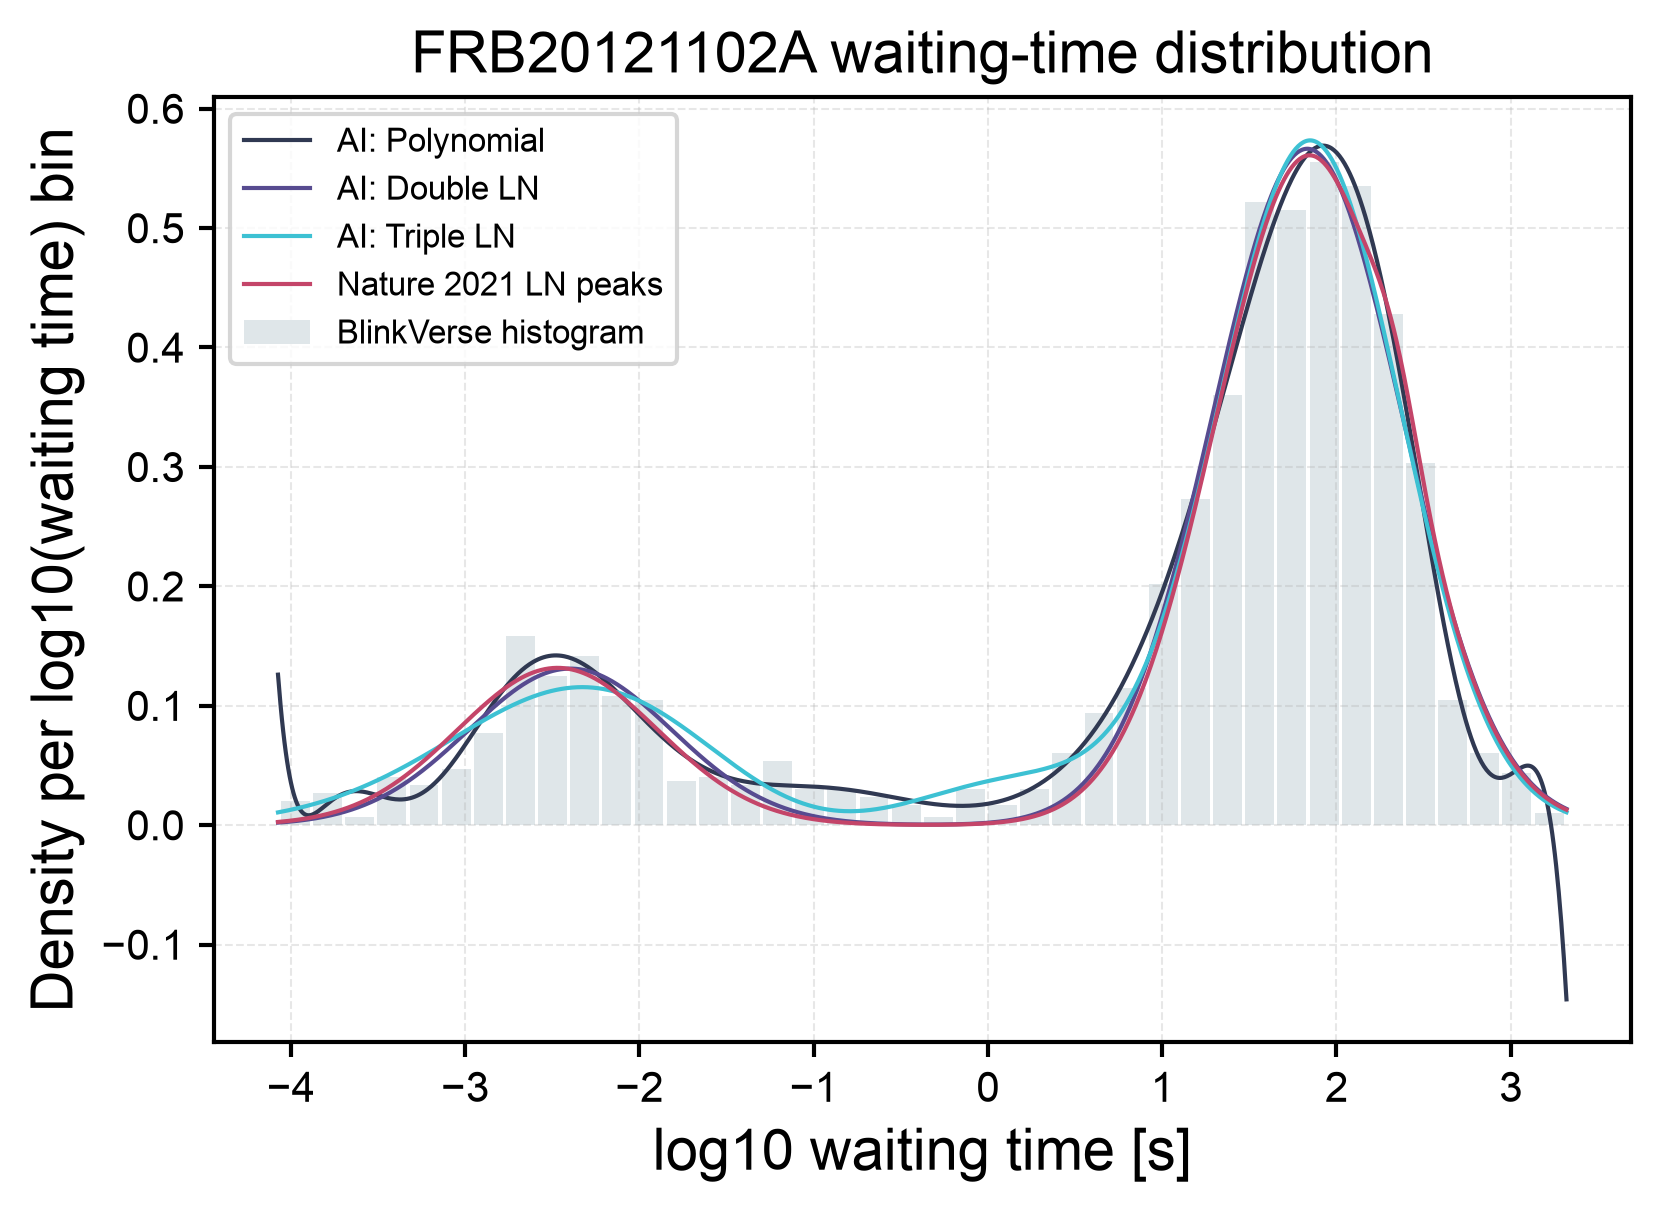

In [15]:
fi, fig, axes = get_fig(1, 1, AW=12, AH=8, dpi=300, fontsize=14, lw=1)
ax = axes[0]

bar_width = 0.9 * np.diff(x).min()
xx = np.linspace(x.min() - 0.1, x.max() + 0.1, 1000)
ax.bar(x, y, width=bar_width, color="#dfe6e9", label="BlinkVerse histogram")
ax.plot(xx, f_ai(xx), color="#303952", lw=1, label="AI: Polynomial")
# ax.plot(xx, f_ai2(xx), color="#546de5", lw=1, label="AI: Single LN")
ax.plot(xx, f_ai3(xx), color="#574b90", lw=1, label="AI: Double LN")
ax.plot(xx, f_ai4(xx), color="#3dc1d3", lw=1, label="AI: Triple LN")
ax.plot(xx, f_nature(xx, *popt), color="#c44569", lw=1, label="Nature 2021 LN peaks")
# ax.axvline(np.log10(3.4e-3), color="#1f6f50", lw=1, ls=":", label="Nature secondary peak 3.4 ms")
# ax.axvline(np.log10(70.0), color="#c44569", lw=1, ls=":", alpha=0.8, label="Nature main peak 70 s")
# ax.axvline(np.log10(220.0), color="#f39c12", lw=1, ls=":", label="Nature high-energy peak 220 s")
ax.set_xlabel("log10 waiting time [s]")
ax.set_ylabel("Density per log10(waiting time) bin")
ax.set_title("FRB20121102A waiting-time distribution")
ax.grid("on", alpha=0.3, linestyle="--", linewidth=0.5)
ax.legend(fontsize=8)


In [19]:
exp_path = Path("logs/overnight_260623_v3/nature2021/dm_evolution")
args = Namespace(**json.load(open(exp_path / 'args.json')))
print(
    f"task={args.task!r}, "
    f"bins={args.bins!r}, "
    f"data_dir={args.data_dir!r}"
)

X, y, problem = build_task(args)
data = X | y
data

task='nature2021_dm_evolution', bins=40, data_dir='data/blinkverse'


{'year_since_mjd_57000': array([ 4.86482632,  4.86482559,  4.86482384, ...,  0.43735585,
         0.43733772, -2.09915719], shape=(2332,)),
 'dm_pc_cm3': array([566. , 567.6, 565.6, ..., 566. , 560. , 553. ], shape=(2332,))}

In [20]:
# AI-discovered formula from the original run with polynomial_fit enabled.
print(json.load(open(exp_path / 'result.json'))['best_formula'])
print('No-polynomial rerun best:', json.load(open('logs/260624_no_poly/dm_evolution_no_poly/result.json'))['best_formula'])

def f_ai(t: np.ndarray) -> np.ndarray:
    """Original best formula in logs/overnight_260623_v3/nature2021/dm_evolution/result.json."""
    return (
        558.3060320651169
        + 1.6644739952547538 * t
        + 35.405291145824656 * np.exp(-((t - 2.7145499178316177) / 0.0002712895118313856) ** 2)
        + 1.0150559220730762 * np.sin(4.8707925960326195 * t + 7.893356687013723)
    )


def f_ai2(t: np.ndarray) -> np.ndarray:
    """No-polynomial rerun: interpretable linear trend."""
    return 561.6240353807519 + 0.9984971058086366 * t


def f_ai3(t: np.ndarray) -> np.ndarray:
    """No-polynomial rerun final best: quadratic trend."""
    return 537.8792644167502 + 19.51174470890554 * t - 2.8506378140254625 * t ** 2


558.3060320651169 + 1.6644739952547538 * year_since_mjd_57000 + 35.405291145824656 * exp(-((year_since_mjd_57000 - 2.7145499178316177) / 0.0002712895118313856) ** 2) + 1.0150559220730762 * sin(4.8707925960326195 * year_since_mjd_57000 + 7.893356687013723)
No-polynomial rerun best: 537.8792644167502 + 19.51174470890554 * year_since_mjd_57000 + -2.8506378140254625 * year_since_mjd_57000 ** 2


In [21]:
t = np.asarray(data["year_since_mjd_57000"], dtype=float)
y = np.asarray(data["dm_pc_cm3"], dtype=float)
order = np.argsort(t)
t, y = t[order], y[order]

def f_nature(t: np.ndarray) -> np.ndarray:
    """Nature 2021 Eq. (2): dDM/dt = +0.85 pc cm^-3 yr^-1.

    The intercept is anchored to the paper's FAST-campaign value
    DM=565.8 pc cm^-3 at the midpoint MJD 58750 of the stated
    MJD 58724-58776 interval.
    """
    t_fast_mid = (58750.0 - 57000.0) / 365.25
    return 565.8 + 0.85 * (t - t_fast_mid)


In [24]:
t = np.asarray(data["year_since_mjd_57000"], dtype=float)
y = np.asarray(data["dm_pc_cm3"], dtype=float)
order = np.argsort(t)
t, y = t[order], y[order]
df_list = []

for model, pred in [
    ('AI: trend + spike + sinusoid', f_ai(t)),
    ('AI: linear trend', f_ai2(t)),
    # ('AI: quadratic trend', f_ai3(t)),
    ('Nature 2021 linear slope +0.85', f_nature(t)),
]:
    df_list.append({
        'model': model,
        'R2': r2_score(y, pred),
        'RMSE': mean_squared_error(y, pred) ** 0.5,
        'MAE': mean_absolute_error(y, pred),
    })

df_metrics = pd.DataFrame(df_list).set_index('model').sort_values('R2')
df_metrics


,R2,RMSE,MAE
model,,,
Nature 2021 linear slope +0.85,0.022658,7.746654,2.782782
AI: linear trend,0.027140,7.728868,2.833155
AI: trend + spike + sinusoid,0.445023,5.837522,1.914317


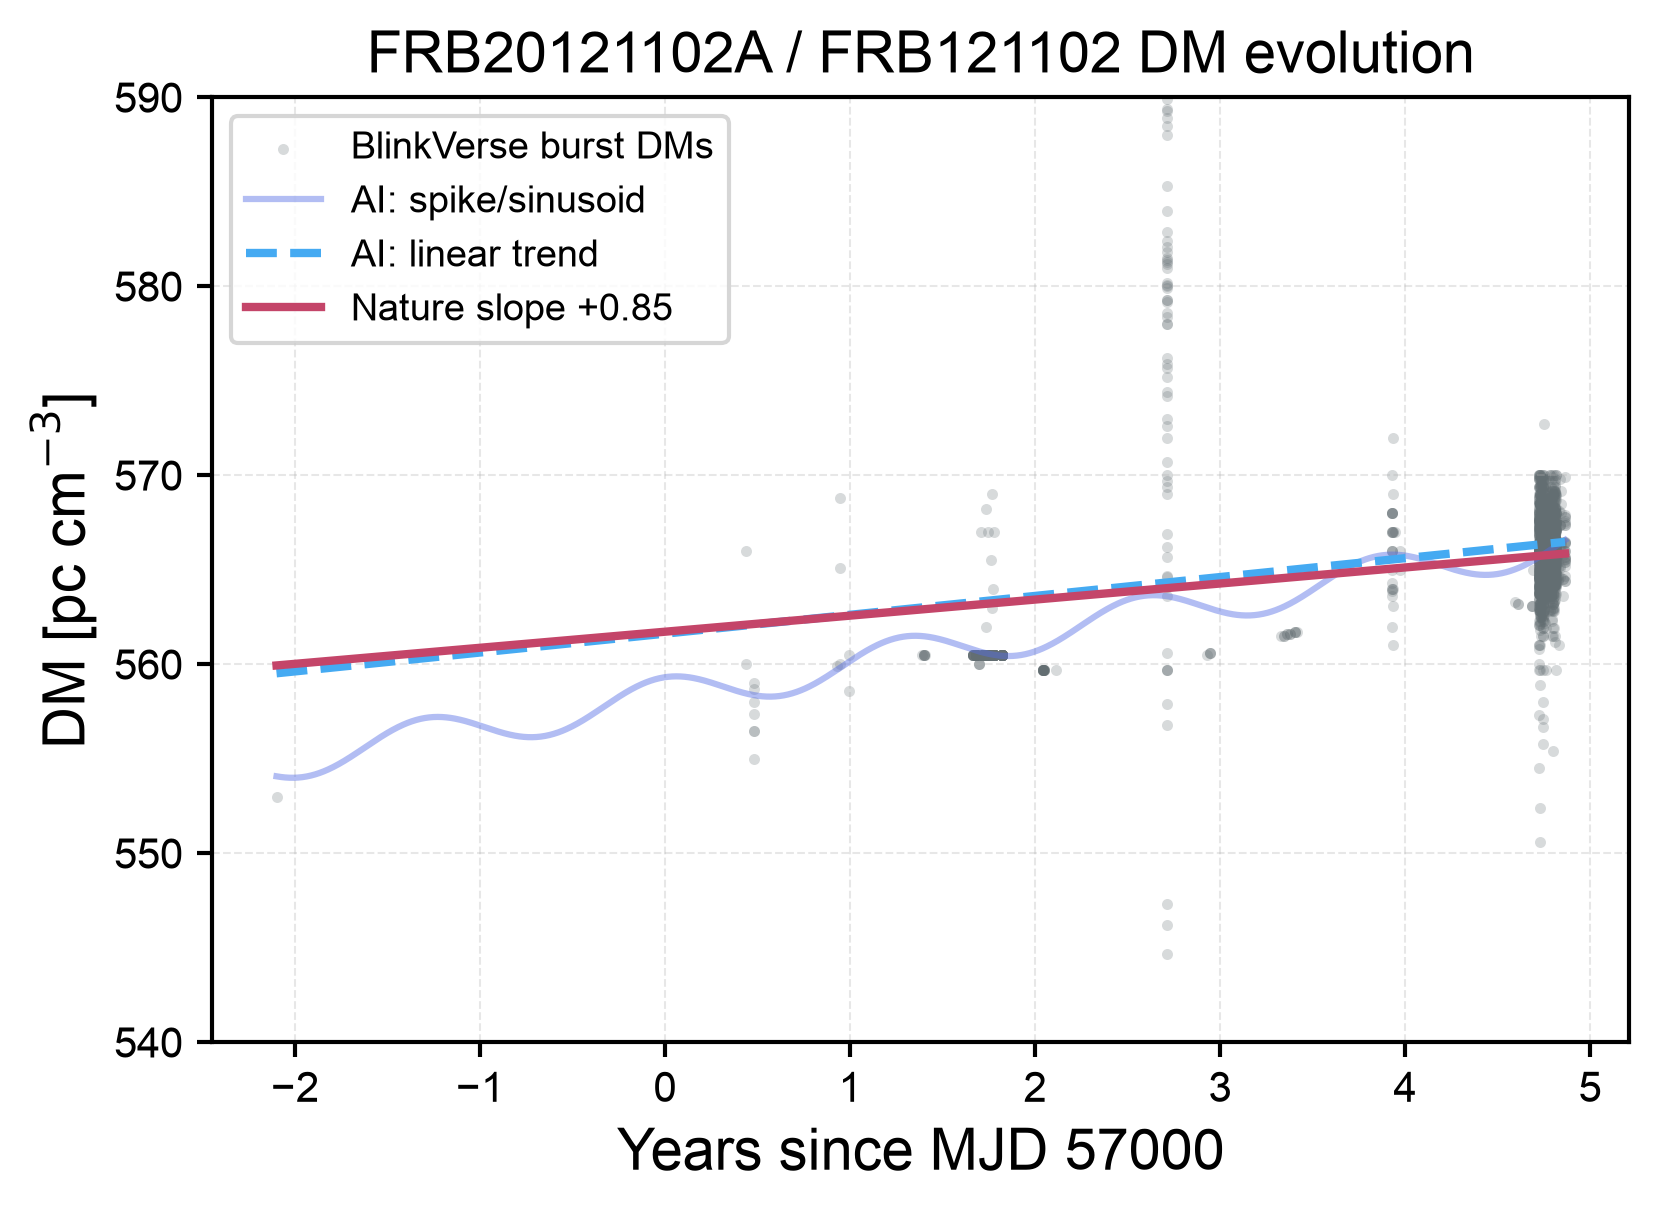

In [23]:
fi, fig, axes = get_fig(1, 1, AW=12, AH=8, dpi=300, fontsize=14, lw=1)
ax = axes[0]

tt = np.linspace(t.min(), t.max(), 1200)
ax.scatter(t, y, s=7, color="#636e72", alpha=0.25, linewidths=0, label="BlinkVerse burst DMs")

# Robust visual summary of the raw scatter: median in 0.25-yr bins.
bins = np.arange(np.floor(t.min() * 4) / 4, np.ceil(t.max() * 4) / 4 + 0.25, 0.25)
bin_id = np.digitize(t, bins) - 1
med_t, med_dm = [], []
for i in range(len(bins) - 1):
    mask = bin_id == i
    if mask.sum() >= 5:
        med_t.append(float(np.median(t[mask])))
        med_dm.append(float(np.median(y[mask])))
# ax.plot(med_t, med_dm, "o", ms=4, color="#2d3436", label="0.25-yr median")
ax.plot(tt, f_ai(tt), color="#546de5", lw=1.5, alpha=0.45, label="AI: spike/sinusoid")
ax.plot(tt, f_ai2(tt), color="#45aaf2", lw=2, ls="--", label="AI: linear trend")
# ax.plot(tt, f_ai3(tt), color="#3867d6", lw=2.2, label="AI: quadratic trend")
ax.plot(tt, f_nature(tt), color="#c44569", lw=2, label="Nature slope +0.85")
# ax.axvspan(
#     (58724.0 - 57000.0) / 365.25,
#     (58776.0 - 57000.0) / 365.25,
#     color="#c44569",
#     alpha=0.08,
#     label="FAST campaign MJD 58724-58776",
# )
ax.set_xlabel("Years since MJD 57000")
ax.set_ylabel("DM [pc cm$^{-3}$]")
ax.set_title("FRB20121102A / FRB121102 DM evolution")
ax.grid("on", alpha=0.3, linestyle="--", linewidth=0.5)
ax.set_ylim(540, 590)
ax.legend(fontsize=9)
